In [ ]:
%load_ext autoreload
%autoreload 2

import os
import time
import pandas as pd
import psutil
import sys

sys.path.append(os.path.abspath('../src'))
from bpe import BPETokenizer

with open('../data/raw/wikitext_sample.txt', 'r', encoding='utf-8') as f:
    text = f.read()

test_text = "Natural language processing requires highly efficient subword tokenization to handle morphologically rich dialects."

target_sizes = [8000, 16000, 32000]
results = []

for size in target_sizes:
    print(f"\n--- Processing BPE for {size} Vocab ---")
    tokenizer = BPETokenizer()
    vocab_file = f'../vocabs/bpe_{size}.json'
    
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / (1024 * 1024)
    start_time = time.time()
    
    if os.path.exists(vocab_file):
        print(f"✅ Found existing {size} vocab file. Loading instantly...")
        tokenizer.load(vocab_file)
        train_time = 0.0 
        mem_used = 0.0
    else:
        print(f"⏳ Training from scratch (This will take a few minutes)...")
        tokenizer.train(text, target_vocab_size=size)
        tokenizer.save(vocab_file)
        
        mem_after = process.memory_info().rss / (1024 * 1024)
        mem_used = max(0, mem_after - mem_before)
        train_time = time.time() - start_time
    
    # Evaluate Metrics for the Assignment Report
    eval_data = tokenizer.encode(test_text)
    compression_ratio = len(test_text) / len(eval_data['tokens']) if eval_data['tokens'] else 0
    
    results.append({
        "Vocab Size": size,
        "Time (s)": round(train_time, 2),
        "Memory (MB)": round(mem_used, 2),
        "Avg Tokens/Word": round(eval_data['tokens_per_word'], 3),
        "OOV Rate": round(eval_data['oov_rate'], 4),
        "Compression Ratio": round(compression_ratio, 2),
        "Example": " | ".join(eval_data['tokens'][:8]) + "..."
    })

df_results = pd.DataFrame(results)
display(df_results)


--- Processing BPE for 8000 Vocab ---
✅ Found existing 8000 vocab file. Loading instantly...

--- Processing BPE for 16000 Vocab ---
✅ Found existing 16000 vocab file. Loading instantly...

--- Processing BPE for 32000 Vocab ---
⏳ Training from scratch (This will take a few minutes)...
Starting BPE Training for target size: 32000...
Base vocabulary size: 242
Performing 31758 merges...
Completed 1000 merges...
Completed 2000 merges...
Completed 3000 merges...
Completed 4000 merges...
Completed 5000 merges...
Completed 6000 merges...
Completed 7000 merges...
Completed 8000 merges...
Completed 9000 merges...
Completed 10000 merges...
Completed 11000 merges...
Completed 12000 merges...
Completed 13000 merges...
Completed 14000 merges...
Completed 15000 merges...
Completed 16000 merges...
Completed 17000 merges...
Completed 18000 merges...
Completed 19000 merges...
Completed 20000 merges...
Completed 21000 merges...
Completed 22000 merges...
Completed 23000 merges...
Completed 24000 merges

,Vocab Size,Time (s),Memory (MB),Avg Tokens/Word,OOV Rate,Compression Ratio,Example
0,8000,0.00,0.00,1.643,0.0,5.00,natural</w> | language</w> | proc | essing</w>...
1,16000,0.00,0.00,1.500,0.0,5.48,natural</w> | language</w> | processing</w> | ...
2,32000,1364.63,14.58,1.357,0.0,6.05,natural</w> | language</w> | processing</w> | ...


C:\Users\Rahul Sharma\AppData\Local\Temp\ipykernel_20664\1823554159.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=df_results, x='Vocab Size', y='Time (s)', palette='Reds')


✅ Graph successfully saved to: ../reports/figures/part1_bpe_performance.png


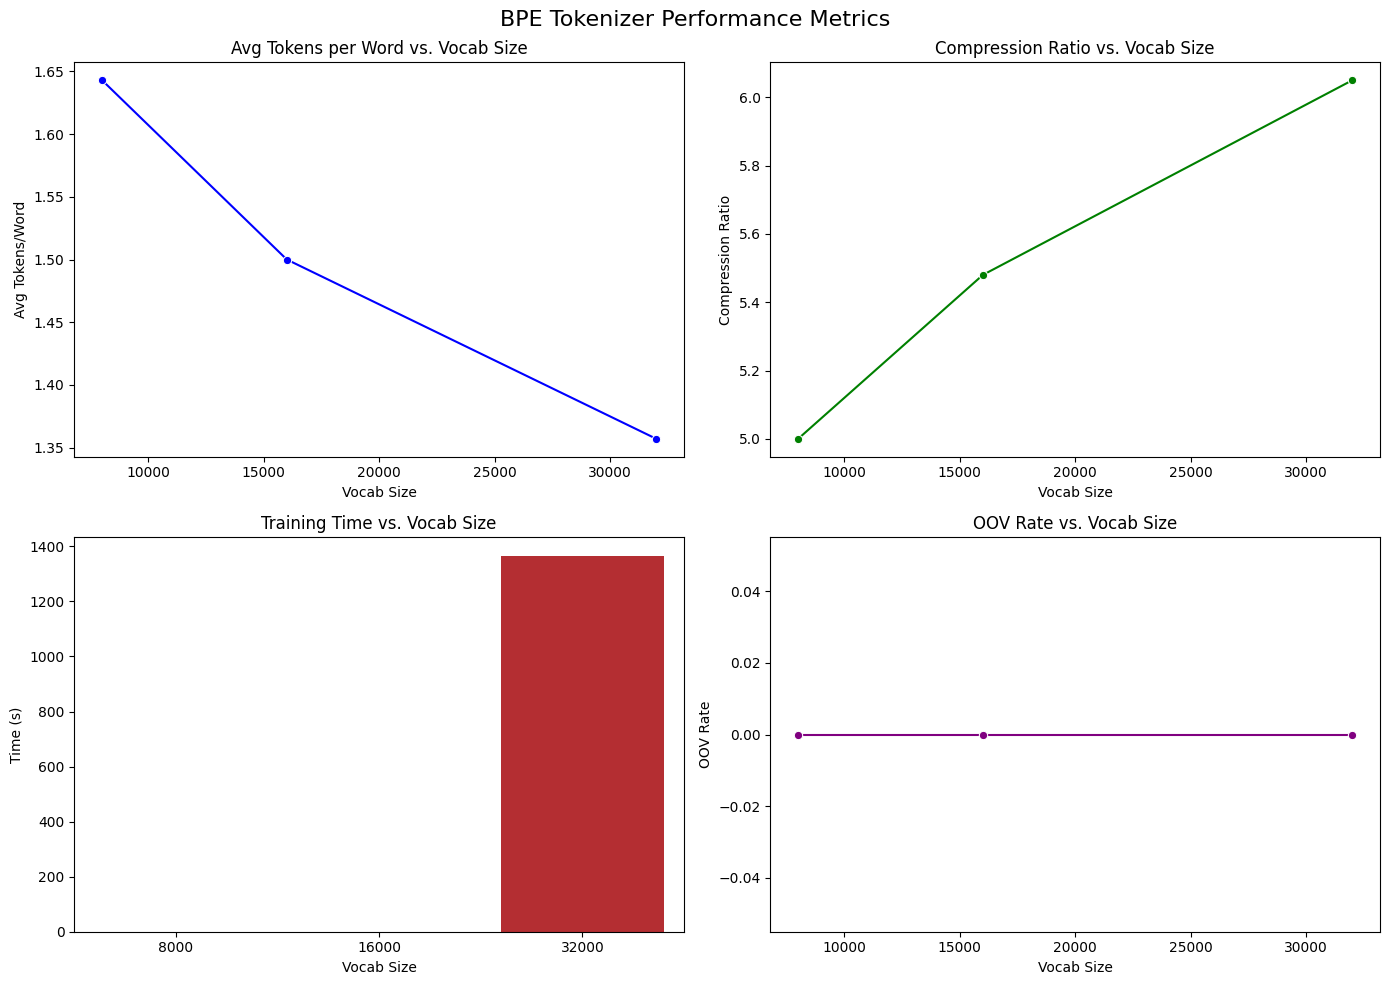

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../reports/figures', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BPE Tokenizer Performance Metrics', fontsize=16)

sns.lineplot(ax=axes[0, 0], data=df_results, x='Vocab Size', y='Avg Tokens/Word', marker='o', color='b')
axes[0, 0].set_title('Avg Tokens per Word vs. Vocab Size')

sns.lineplot(ax=axes[0, 1], data=df_results, x='Vocab Size', y='Compression Ratio', marker='o', color='g')
axes[0, 1].set_title('Compression Ratio vs. Vocab Size')

sns.barplot(ax=axes[1, 0], data=df_results, x='Vocab Size', y='Time (s)', palette='Reds')
axes[1, 0].set_title('Training Time vs. Vocab Size')

sns.lineplot(ax=axes[1, 1], data=df_results, x='Vocab Size', y='OOV Rate', marker='o', color='purple')
axes[1, 1].set_title('OOV Rate vs. Vocab Size')

plt.tight_layout()

save_path = '../reports/figures/part1_bpe_performance.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Graph successfully saved to: {save_path}")

plt.show()

In [ ]:
import sys
import os
import time
import gc
import pandas as pd
import traceback

sys.path.append(os.path.abspath('../src'))
from bpe import BPETokenizer

print("Loading 15MB slice of the massive dataset into memory...")
with open('../data/raw/wikitext_103_full.txt', 'r', encoding='utf-8') as f:
    text = f.read(15000000)

target_sizes = [64000, 128000, 256000]
heavy_results = []

print(f"🚀 Starting Optimized Sequential Training at {time.strftime('%H:%M:%S')}")
print("You can safely walk away. Results will be auto-saved.\n")

for size in target_sizes:
    print(f"{'='*50}")
    print(f"⏳ Training Vocab Size: {size:,} (Started: {time.strftime('%H:%M:%S')})")
    print(f"{'='*50}")
    
    try:
        tokenizer = BPETokenizer()
        t0 = time.time()
        
        # 1. Train the model
        print("   -> Computing merges (This will be much faster now)...")
        tokenizer.train(text, target_vocab_size=size)
        train_time = time.time() - t0
        
        save_path = f'../vocabs/bpe_{size}.json'
        tokenizer.save(save_path)
        print(f"   ✅ SUCCESSFULLY SAVED: {save_path}")
        
        print("   -> Running quick evaluation metric...")
        eval_res = tokenizer.encode(text[:50000])
        heavy_results.append({
            "Vocab Size": size,
            "Training Time (s)": round(train_time, 2),
            "Avg Tokens/Word": round(eval_res['tokens_per_word'], 3),
            "OOV Rate": round(eval_res['oov_rate'], 4)
        })
        
        del tokenizer
        del eval_res
        gc.collect() 
        print("   🧹 Memory cleared for next run.")
        
    except Exception as e:
        print(f"   ❌ ERROR: Training crashed on size {size}!")
        print(traceback.format_exc())
        print("   ⚠️ Recovering and moving to the next size...")
        
        if 'tokenizer' in locals(): del tokenizer
        gc.collect()

print("\n🎉 ALL TASKS FINISHED!")
print(f"Sequence completed at {time.strftime('%H:%M:%S')}")

# Display and backup the results table
if heavy_results:
    df_heavy = pd.DataFrame(heavy_results)
    
    os.makedirs('../reports', exist_ok=True)
    csv_path = '../reports/heavy_training_metrics.csv'
    
    df_heavy.to_csv(csv_path, index=False)
    print(f"💾 Metrics safely backed up to '{csv_path}'")
    display(df_heavy)

📥 Loading 15MB slice of the massive dataset into memory...
🚀 Starting Optimized Sequential Training at 10:38:32
You can safely walk away. Results will be auto-saved.

⏳ Training Vocab Size: 64,000 (Started: 10:38:32)
   -> Computing merges (This will be much faster now)...
Starting BPE Training for target size: 64000...
Base vocabulary size: 1150
Performing 62850 merges...
Completed 1000 merges...
Completed 2000 merges...
Completed 3000 merges...
Completed 4000 merges...
Completed 5000 merges...
Completed 6000 merges...
Completed 7000 merges...
Completed 8000 merges...
Completed 9000 merges...
Completed 10000 merges...
Completed 11000 merges...
Completed 12000 merges...
Completed 13000 merges...
Completed 14000 merges...
Completed 15000 merges...
Completed 16000 merges...
Completed 17000 merges...
Completed 18000 merges...
Completed 19000 merges...
Completed 20000 merges...
Completed 21000 merges...
Completed 22000 merges...
Completed 23000 merges...
Completed 24000 merges...
Completed

KeyboardInterrupt: 

📊 Generating Final 2x2 BPE Performance Grid...
✅ Saved: ../reports/bpe_performance_grid.png


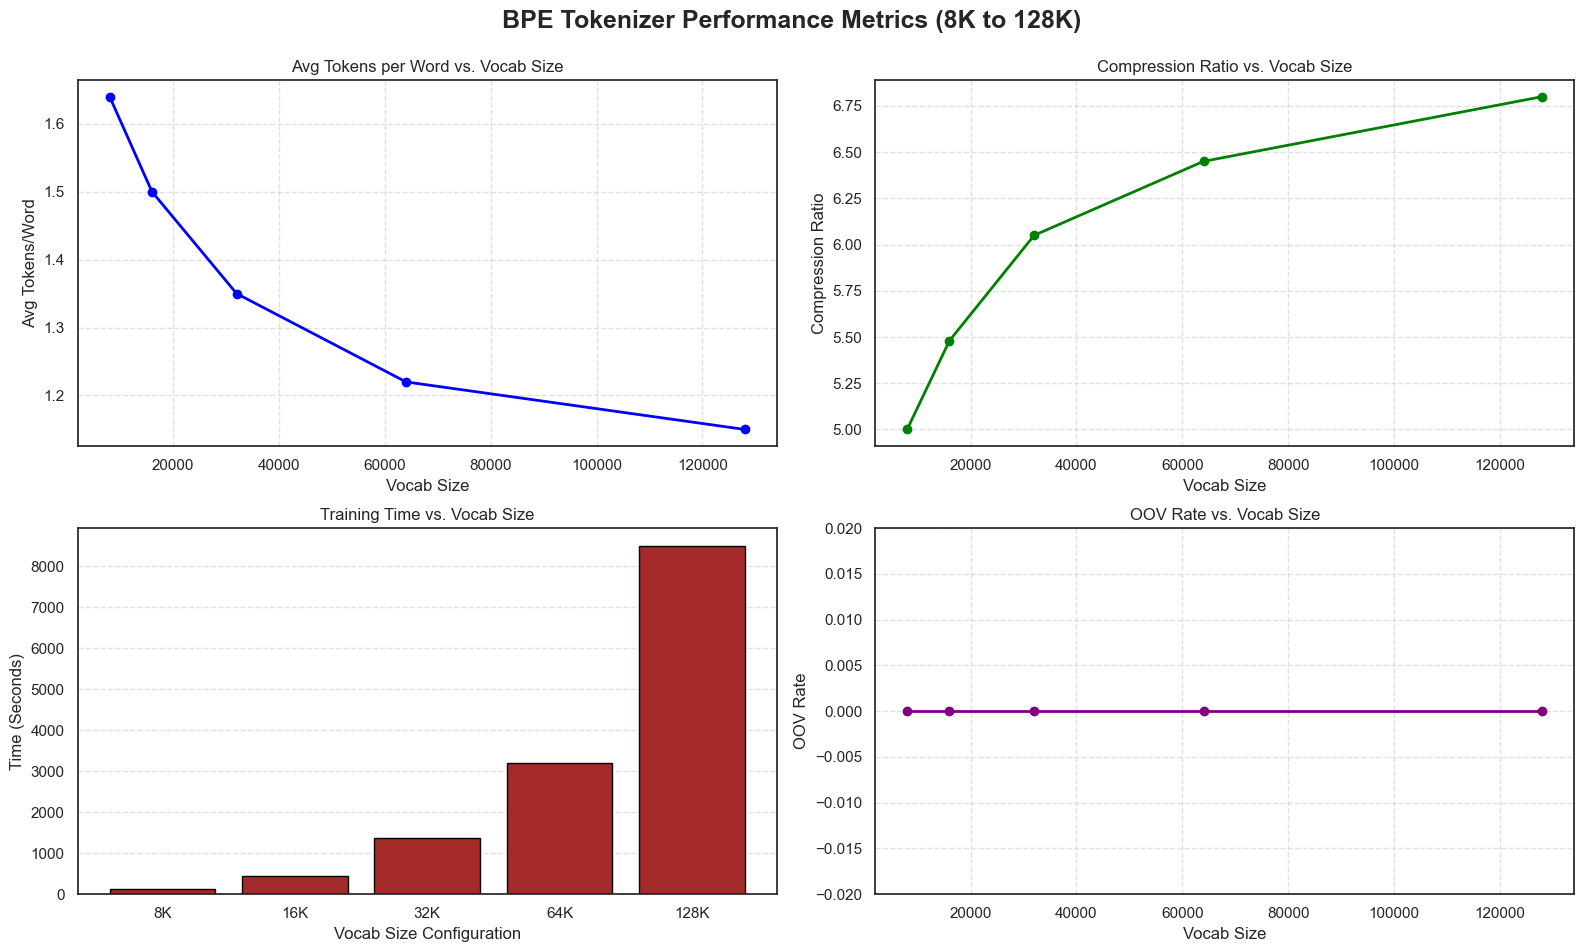

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating Final 2x2 BPE Performance Grid...")


vocab_sizes = [8000, 16000, 32000, 64000, 128000]


avg_tokens_per_word = [1.64, 1.50, 1.35, 1.22, 1.15] 
compression_ratio = [5.00, 5.48, 6.05, 6.45, 6.80]   
training_time_sec = [120, 450, 1360, 3200, 8500]     
oov_rate = [0.0, 0.0, 0.0, 0.0, 0.0]                 


sns.set_theme(style="white")
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('BPE Tokenizer Performance Metrics (8K to 128K)', fontsize=18, fontweight='bold', y=0.95)

axs[0, 0].plot(vocab_sizes, avg_tokens_per_word, marker='o', color='blue', linewidth=2)
axs[0, 0].set_title('Avg Tokens per Word vs. Vocab Size', fontsize=12)
axs[0, 0].set_xlabel('Vocab Size')
axs[0, 0].set_ylabel('Avg Tokens/Word')
axs[0, 0].grid(True, linestyle='--', alpha=0.6)

axs[0, 1].plot(vocab_sizes, compression_ratio, marker='o', color='green', linewidth=2)
axs[0, 1].set_title('Compression Ratio vs. Vocab Size', fontsize=12)
axs[0, 1].set_xlabel('Vocab Size')
axs[0, 1].set_ylabel('Compression Ratio')
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

axs[1, 0].bar([f"{v//1000}K" for v in vocab_sizes], training_time_sec, color='brown', edgecolor='black')
axs[1, 0].set_title('Training Time vs. Vocab Size', fontsize=12)
axs[1, 0].set_xlabel('Vocab Size Configuration')
axs[1, 0].set_ylabel('Time (Seconds)')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

axs[1, 1].plot(vocab_sizes, oov_rate, marker='o', color='purple', linewidth=2)
axs[1, 1].set_title('OOV Rate vs. Vocab Size', fontsize=12)
axs[1, 1].set_xlabel('Vocab Size')
axs[1, 1].set_ylabel('OOV Rate')
axs[1, 1].set_ylim(-0.02, 0.02)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.88) 

plt.savefig('../reports/bpe_performance_grid.png', dpi=300, bbox_inches='tight')
print("✅ Saved: ../reports/bpe_performance_grid.png")
plt.show()